# 컨설팅 대상 세그먼트 선정 EDA
**팀 논의용 | 평가 기준: 2025년 | 반도체 분류: 지정 목록 20개사**

사용 자료는 **「세그먼트 기준 확정 EDA.xlsx」와 「반도체 업종.xlsx」 두 파일**입니다. 첫 번째 파일에서 등급·시가총액·보고서·과거 평가를 분석하고, 두 번째 파일의 기업 목록으로 업종을 구분합니다. 자산총액은 추가로 DART API에서 수집하도록 연결했습니다.

컨설팅 대상으로 **어떤 기업군부터 수요를 확인할지** 결정하기 위한 자료입니다. 낮은 등급은 개선 과제 탐색의 단서이고 시가총액은 규모의 대용치입니다. 계약 의향·예산·실제 개선 가능성을 입증하지는 않습니다.

읽는 순서: **핵심 결과 → 데이터 점검 → 업종 분류 → 등급·규모 비교 → 후보군 비교 → 팀 결정표**. 표와 차트는 실행 결과를 포함합니다.

**사용자 확정 분류:** ‘반도체 업종.xlsx’의 **20개사만 반도체**, 나머지 **69개사는 비반도체**입니다. C261은 분류 배경과 대조용 정보이며 목록 밖 기업을 추가하는 조건으로 사용하지 않습니다. 기업코드로 연결하고 기업명을 대조합니다. 전체 분석 대상은 89개사입니다.

**추가 기준:** 사용자가 제시한 ‘2030년·자산총액 2조원 이상’을 별도 분석 가정으로 적용합니다. DART에서 2025 사업연도 자산총액을 수집해 적용했습니다. 연결/별도 여부와 조회 상태는 기업별 표에 표시합니다.

## 1. 먼저 볼 핵심 결과
- 352행 중 기업·연도가 있는 348행을 사용합니다. 2025년 분석 대상은 **89개사**이며 시가총액 결측은 없습니다.
- 지정 목록을 최종 기준으로 **반도체 20개사 / 비반도체 69개사**로 분류합니다.
- 우선 논의할 **A 기초 개선형(C·D, 3천억~1조 미만)**은 반도체 **6개사**, 비반도체 **7개사**입니다.
- **B 등급 향상형(B·B+, 같은 규모)**은 각각 **1개사 / 10개사**입니다. 반도체는 B·B+만으로 좁히면 선택 폭이 작습니다.
- **C 소규모 기초형(C·D, 3천억 미만)**은 각각 **5개사 / 21개사**, **D 대형 개선형(C·D, 1조 이상)**은 **3개사 / 7개사**입니다.

**제안:** 반도체는 중간 규모 C·D 6개사를 첫 진단 후보로, 비반도체는 중간 규모 C·D 7개사와 B·B+ 10개사를 서비스 적합성으로 비교합니다. 특정 세그먼트가 통계적으로 최적이라는 뜻은 아닙니다.

※ 위 숫자는 두 원본 파일과 기본 규모 경계값 기준입니다. 설정·입력을 바꾸면 표와 차트를 다시 실행하고 고정 설명의 수치도 갱신하세요.

**DART 자산 기준 결과(2025 사업연도):**
- 반도체: 2조원 이상 **4개사**, 미만 **16개사**, 확인 필요 **0개사**
- 비반도체: 2조원 이상 **20개사**, 미만 **48개사**, 확인 필요 **1개사**
- 2조원 이상·C·D: 반도체 **1개사**, 비반도체 **2개사**
- 2조원 이상·B·B+: 반도체 **1개사**, 비반도체 **6개사**

자산 기준 후보는 시가총액 중간 규모 후보와 별개입니다. 자산 2조원 이상 여부로 먼저 나눈 뒤 등급에 맞는 서비스를 검토할 수 있습니다.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import hashlib

# 지정된 평가 원본과 업종 목록만 읽습니다. 노트북과 두 엑셀을 같은 폴더에 두세요.
FILE_NAME = '세그먼트 기준 확정 EDA.xlsx'
INPUT_PATH = Path.cwd() / FILE_NAME
if not INPUT_PATH.exists():
    INPUT_PATH = Path('C:/hewon/esg-rag-scoring/docs/등급표') / FILE_NAME
assert INPUT_PATH.is_file(), 'INPUT_PATH를 지정된 원본 엑셀 위치로 수정하세요.'

LOWER_CAP, UPPER_CAP = 3000e8, 1e12  # 원 단위: 3천억원, 1조원
SECTORS = ['반도체', '비반도체']
GRADE_ORDER = ['D', 'C', 'B', 'B+', 'A', 'A+', 'S']
GRADE_SCORE = {g:i for i,g in enumerate(GRADE_ORDER)}
GRADE_GROUPS = ['C·D', 'B·B+', 'A 이상']
CAP_LABELS = ['하위 규모', '중간 규모', '상위 규모']
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'axes.unicode_minus': False, 'figure.dpi': 120, 'font.size': 11})
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
try:
    from IPython.display import display
except ImportError:
    if 'display' not in globals():
        def display(x): print(x.to_string(index=False) if isinstance(x, pd.DataFrame) else x)

raw = pd.read_excel(INPUT_PATH, sheet_name='260907_고객 세그먼트 분류용')
print('원본:', INPUT_PATH.name)
print('SHA256:', hashlib.sha256(INPUT_PATH.read_bytes()).hexdigest())
print('원본 행 수:', len(raw))
print(f'규모 기준: 하위 < {LOWER_CAP/1e8:,.0f}억원 / 중간 < {UPPER_CAP/1e8:,.0f}억원 / 상위 그 이상')

SECTOR_PATH = INPUT_PATH.parent / '반도체 업종.xlsx'
assert SECTOR_PATH.is_file(), '반도체 업종.xlsx를 원본과 같은 폴더에 두세요.'
# 헤더가 없는 파일입니다. 첫 기업의 2022년 행도 포함하도록 header=None 사용.
sector_raw = pd.read_excel(SECTOR_PATH, sheet_name='반도체 업종', header=None)
sector_valid = pd.to_numeric(sector_raw[1], errors='coerce').notna() & pd.to_numeric(sector_raw[3], errors='coerce').notna()
sector_rows = sector_raw.loc[sector_valid, [0,1,2,3]].copy()
sector_rows.columns = ['목록기업명','기업코드','목록산업코드','목록평가년도']
sector_rows['기업코드'] = pd.to_numeric(sector_rows['기업코드']).astype(int).astype(str).str.zfill(6)
sector_rows['목록기업명'] = sector_rows['목록기업명'].astype('string').str.strip()
assert sector_rows.groupby('기업코드')['목록기업명'].nunique().le(1).all()
sector_list = sector_rows[['기업코드','목록기업명']].drop_duplicates()
sector_codes = set(sector_list['기업코드'])
print('업종 목록:', SECTOR_PATH.name)
print('SHA256:', hashlib.sha256(SECTOR_PATH.read_bytes()).hexdigest())
print(f'업종 목록 유효 평가 행 {len(sector_rows)}개 / 중복 제거 기업 {len(sector_list)}개')
display(sector_raw.loc[~sector_valid & sector_raw[0].notna(), [0]].rename(columns={0:'목록 파일의 비기업 행(집계 제외)'}))

# 자산 자료가 제공되면 동일 기준연도·연결/별도 기준으로 확인한 값을 원 단위로 입력합니다.
# 기업코드는 6자리 문자열. 미제공 상태를 0으로 채우지 마세요.
ASSET_THRESHOLD = 2e12
ASSET_BY_CODE = {}
ASSET_BASE_YEAR = None
ASSET_SCOPE = None  # '연결' 또는 '별도' 등 실제 제공 기준


원본: 세그먼트 기준 확정 EDA.xlsx
SHA256: 2d5c697857e29e91a369a57f8edf086004da2db83ae2062ba69209d014f16bec
원본 행 수: 352
규모 기준: 하위 < 3,000억원 / 중간 < 10,000억원 / 상위 그 이상
업종 목록: 반도체 업종.xlsx
SHA256: 164519a05534f6ce5f609e760b536103afdb4b5d1fa0676824203484a3a36917
업종 목록 유효 평가 행 79개 / 중복 제거 기업 20개


,목록 파일의 비기업 행(집계 제외)
81,20
98,"제외: 가온칩스, 시노펙스, 에코프로머티, 유티아이, 제주반도체, 칩스앤미디어"


## 2. 데이터 품질과 분석 단위
기업코드·평가년도가 없는 4행은 빈 행과 메모이므로 제외합니다. 메모는 아래에 보존합니다. 회사명 변경이 있어도 기업코드를 연결 키로 사용합니다. 최신 연도에 없는 기업을 과거 연도 자료로 채워 넣지 않습니다.

시가총액은 **2025년 평가 행에 붙어 있는 가격 자료**입니다. 가격 기준일·통화 단위 설명이 별도로 없으므로 원 단위로 가정해 억원으로 환산합니다. ‘2025년 말 시가총액’이나 ‘현재 시가총액’으로 해석하지 않습니다. 가격 기준일과 단위 확인은 팀의 확정 조건입니다.

In [2]:
invalid = raw['기업코드'].isna() | raw['평가년도'].isna()
display(raw.loc[invalid, ['기업명']].fillna('(빈 행)').rename(columns={'기업명':'제외 행 원문'}))
df = raw.loc[~invalid].copy()
df['기업코드'] = pd.to_numeric(df['기업코드']).astype(int).astype(str).str.zfill(6)
df['평가년도'] = pd.to_numeric(df['평가년도']).astype(int)
for c in ['기업명', '산업코드', 'ESG등급', '환경', '사회', '지배구조']:
    df[c] = df[c].astype('string').str.strip()
assert not df.duplicated(['기업코드','평가년도']).any(), '기업·연도 중복을 먼저 확인하세요.'
assert all(set(df[c].dropna()) <= set(GRADE_ORDER) for c in ['ESG등급','환경','사회','지배구조'])
year = int(df['평가년도'].max())
latest = df.loc[df['평가년도'].eq(year)].copy()
assert latest['기업코드'].is_unique
assert latest['시가총액'].notna().all() and latest['시가총액'].gt(0).all()
display(df.groupby('평가년도').agg(평가기업수=('기업코드','nunique'), 시가총액보유=('시가총액','count')).reset_index())
display(latest[['기업코드','산업코드','ESG등급','환경','사회','지배구조','시가총액',
                '지속가능경영보고서_발행','기업지배구조보고서_발행']].isna().sum().rename('최신연도 결측수').to_frame())
excluded = df.loc[~df['기업코드'].isin(latest['기업코드'])]
display(excluded.groupby('기업코드').agg(기업명=('기업명','last'), 마지막평가년도=('평가년도','max')).reset_index())
print(f'분석용 {len(df)}행 / 최신 {year}년 {len(latest)}개사')


,제외 행 원문
348,(빈 행)
349,*033180_KH필룩스_상장폐지
350,네패스 보고서안나와서 삭제
351,*007340_디티알오토모티브' > 'DN오토모티브'는 동일 법인의 변경 전후 사명...


,평가년도,평가기업수,시가총액보유
0,2022,83,0
1,2023,86,0
2,2024,90,0
3,2025,89,89


,최신연도 결측수
기업코드,0
산업코드,0
ESG등급,0
환경,0
사회,0
지배구조,0
시가총액,0
지속가능경영보고서_발행,0
기업지배구조보고서_발행,0


,기업코드,기업명,마지막평가년도
0,033240,자화전자,2023
1,060720,KH바텍,2024
2,061970,LB세미콘,2024


분석용 348행 / 최신 2025년 89개사


### 품질 이슈의 해석
- 2025년 분석에 없는 과거 기업은 자화전자·KH바텍·LB세미콘입니다. 연도별 전체 비율 변화에는 구성 변화가 섞이므로, 추세는 같은 기업끼리 비교합니다.
- 하단 메모에 ‘네패스 보고서안나와서 삭제’가 있지만 네패스의 평가 행이 존재합니다. 메모만으로 기업을 삭제하지 않고 검토 대상으로 남깁니다.
- 보고서 발행 여부와 비고/확인 메모가 다를 수 있습니다. 발행 플래그를 기본 집계값으로 유지하고, 비고는 별도 검토합니다.
- 등급 조정 메모를 이용해 임의로 등급을 재계산하지 않습니다. 기록된 등급을 사용합니다.
- 이 파일에 담긴 기업들의 분포이며, 전체 상장사나 전체 반도체 산업의 대표 표본이라고 볼 근거는 없습니다.

## 3. 업종 구분: 지정 목록 20개사 확정
**반도체 = ‘반도체 업종.xlsx’의 20개 기업코드. 비반도체 = 나머지 69개사.**

업종 파일은 열 제목이 없고 연도별 행이 반복됩니다. 기업코드와 평가연도가 있는 79행에서 중복을 제거하면 20개사입니다. 하단의 숫자·빈 행·‘제외’ 메모는 기업 목록으로 읽지 않습니다.

- 목록 중 원본 산업코드가 C261로 시작하는 기업: **13개사**
- 목록 중 C261 외 기업: **7개사** — 리노공업·삼성전자·에스앤에스텍·에프에스티·주성코퍼레이션·해성디에스·RFHIC
- **일진디스플·HD현대에너지솔루션**은 원본 산업코드가 C261 계열이어도 지정 목록에 없으므로 **비반도체**로 분류합니다.

C261 여부와 목록 포함 여부를 합집합으로 처리하지 않습니다. 사용자 지정 목록을 최종 기준으로 적용합니다. 평가·시가총액·보고서 값은 첫 번째 원본을 사용하며, 두 기업 역시 전체 분석 대상에는 유지합니다.

In [3]:
assert sector_codes <= set(latest['기업코드']), '목록 중 최신 분석 대상에 없는 기업을 확인하세요.'
name_check = sector_list.merge(latest[['기업코드','기업명']],on='기업코드',validate='one_to_one')
assert name_check['목록기업명'].eq(name_check['기업명']).all(), '기업코드별 이름 차이를 확인하세요.'
base_mask = latest['산업코드'].str.startswith('C261', na=False)
list_mask = latest['기업코드'].isin(sector_codes)
latest['업종군'] = np.where(list_mask, '반도체', '비반도체')
latest['분류근거'] = np.select(
    [base_mask & list_mask, base_mask & ~list_mask, ~base_mask & list_mask],
    ['목록 포함 · C261', '목록 제외 · C261 (비반도체)', '목록 포함 · C261 외'], default='목록 제외 · C261 외')
display(latest.groupby(['업종군','분류근거']).size().rename('기업수').to_frame())
display(latest.loc[~base_mask & list_mask,['기업코드','기업명','산업코드','분류근거']])
display(latest.loc[base_mask & ~list_mask,['기업코드','기업명','산업코드','분류근거']])
assert int((~base_mask & list_mask).sum()) == 7
assert latest['업종군'].eq('반도체').sum() == 20
latest['시가총액_억원'] = latest['시가총액']/1e8
latest['규모군'] = pd.cut(latest['시가총액'], [0, LOWER_CAP, UPPER_CAP, np.inf],
                          labels=CAP_LABELS, right=False)
latest['등급군'] = latest['ESG등급'].map({'C':'C·D','D':'C·D','B':'B·B+','B+':'B·B+','A':'A 이상','A+':'A 이상','S':'A 이상'})
assert latest[['업종군','규모군','등급군']].notna().all().all()
display(latest.groupby('업종군').agg(기업수=('기업코드','size'), 시총중앙값_억원=('시가총액_억원','median')).reindex(SECTORS))
display(latest.groupby(['업종군','산업코드']).agg(기업수=('기업명','size'), 기업목록=('기업명',lambda s:', '.join(s))).reset_index())


기업수
업종군  분류근거                    
반도체  목록 포함 · C261          13
     목록 포함 · C261 외         7
비반도체 목록 제외 · C261 (비반도체)    2
     목록 제외 · C261 외        67

,기업코드,기업명,산업코드,분류근거
68,058470,리노공업,C2629,목록 포함 · C261 외
80,005930,삼성전자,C264,목록 포함 · C261 외
165,101490,에스앤에스텍,C2629,목록 포함 · C261 외
179,036810,에프에스티,C2629,목록 포함 · C261 외
232,109070,주성코퍼레이션,C264,목록 포함 · C261 외
280,195870,해성디에스,C262,목록 포함 · C261 외
336,218410,RFHIC,C264,목록 포함 · C261 외


,기업코드,기업명,산업코드,분류근거
219,020760,일진디스플,C261,목록 제외 · C261 (비반도체)
300,322000,HD현대에너지솔루션,C2612,목록 제외 · C261 (비반도체)


,기업수,시총중앙값_억원
업종군,,
반도체,20,"7,759.0"
비반도체,69,"6,386.3"


,업종군,산업코드,기업수,기업목록
0,반도체,C261,1,네패스
1,반도체,C2611,4,"와이투솔루션, 하나마이크론, DB하이텍, SFA반도체"
2,반도체,C2612,8,"광전자, 서울반도체, 시그네틱스, 신성이엔지, 하나머티리얼즈, KEC, LX세미콘,..."
3,반도체,C262,1,해성디에스
4,반도체,C2629,3,"리노공업, 에스앤에스텍, 에프에스티"
5,반도체,C264,3,"삼성전자, 주성코퍼레이션, RFHIC"
6,비반도체,C261,1,일진디스플
7,비반도체,C2612,1,HD현대에너지솔루션
8,비반도체,C262,5,"덕산네오룩스, 써니전자, 이엠텍, 제이앤티씨, LG이노텍"
9,비반도체,C2621,1,LG디스플레이


## 4. 등급과 시가총액의 분포
등급은 순서가 있는 범주이므로 **기업 수와 비율**로 비교합니다. 평균 등급 점수는 계산하지 않습니다. 시가총액은 대형 기업의 영향이 크므로 중앙값·사분위수를 함께 보고, 그림의 시가총액 축은 로그 척도를 사용합니다.

3천억·1조 기준은 서비스 대상 규모를 논의하기 쉬운 **제안 경계값**입니다. 공인 기업 규모 기준이나 통계적으로 최적화된 기준이 아닙니다. 정확히 3천억인 기업은 중간, 1조인 기업은 상위에 포함합니다.

ESG등급,D,C,B,B+,A,A+,S,합계
업종군,,,,,,,,
반도체,7,7,1,1,4,0,0,20
비반도체,27,8,6,12,15,1,0,69


업종 내 비율(%),D,C,B,B+,A,A+,S
업종군,,,,,,,
반도체,35.0,35.0,5.0,5.0,20.0,0.0,0.0
비반도체,39.1,11.6,8.7,17.4,21.7,1.4,0.0


,count,mean,std,min,25%,50%,75%,max
업종군,,,,,,,,
반도체,20.0,"600,206.6","1,858,640.7",418.3,"2,832.2","7,759.0","12,001.6","7,097,645.9"
비반도체,69.0,"44,409.2","116,309.4",194.0,"1,934.5","6,386.3","20,487.7","862,290.0"


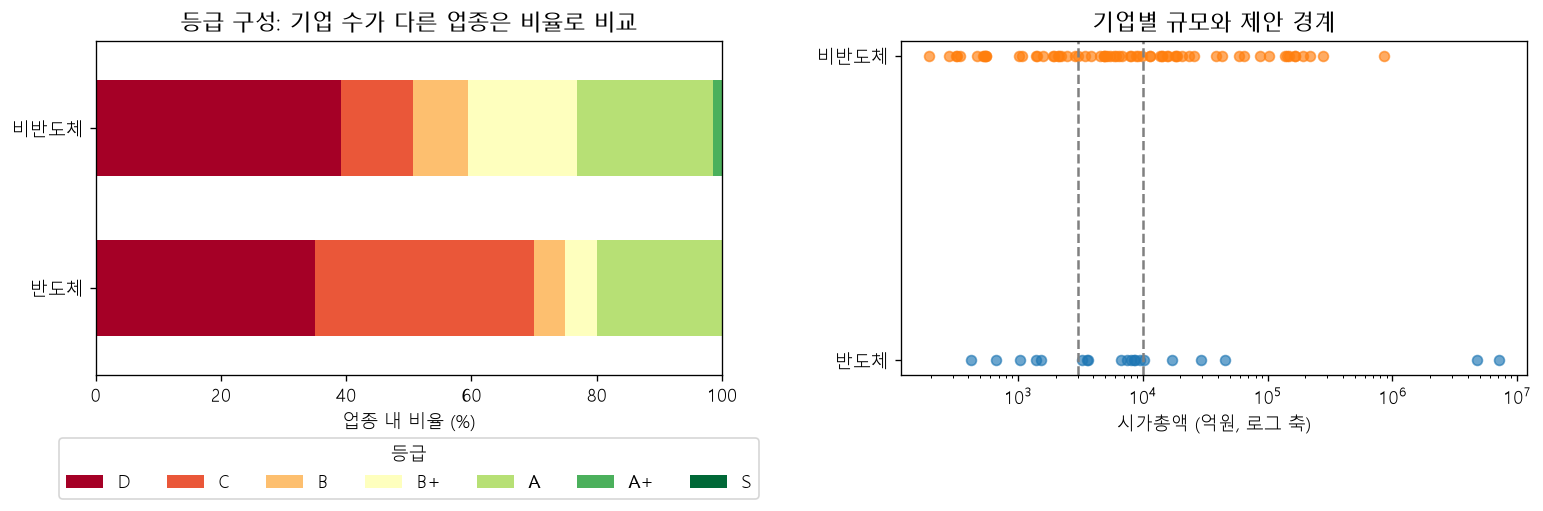

,기업명,업종군,시가총액_억원,전체 시총 비중(%)
80,삼성전자,반도체,"7,097,645.9",47.1
347,SK하이닉스,반도체,"4,739,295.4",31.5
320,LG에너지솔루션,비반도체,"862,290.0",5.7
304,HD현대일렉트릭,비반도체,"279,005.0",1.9
84,삼성SDI,비반도체,"217,178.0",1.4


해석: 평균·합계 시총은 초대형 기업에 좌우될 수 있습니다. 대상 기업 수와 중앙값을 우선 보세요.


In [4]:
grade_counts = pd.crosstab(latest['업종군'], latest['ESG등급']).reindex(index=SECTORS, columns=GRADE_ORDER, fill_value=0)
grade_pct = grade_counts.div(grade_counts.sum(axis=1), axis=0)*100
display(grade_counts.rename_axis(columns='ESG등급').assign(합계=lambda x:x.sum(axis=1)))
display(grade_pct.round(1).rename_axis(columns='업종 내 비율(%)'))
display(latest.groupby('업종군')['시가총액_억원'].describe(percentiles=[.25,.5,.75]).reindex(SECTORS))
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
grade_pct.plot.barh(stacked=True, ax=axes[0], colormap='RdYlGn', width=.6)
axes[0].set(xlabel='업종 내 비율 (%)', ylabel='', title='등급 구성: 기업 수가 다른 업종은 비율로 비교')
axes[0].legend(title='등급', bbox_to_anchor=(.5,-.16),loc='upper center',ncol=7)
for i,s in enumerate(SECTORS):
    x=latest.loc[latest['업종군'].eq(s),'시가총액_억원']
    axes[1].scatter(x,np.full(len(x),i),alpha=.65,s=35)
axes[1].set_xscale('log')
axes[1].set_yticks(range(2),SECTORS)
axes[1].set(xlabel='시가총액 (억원, 로그 축)',title='기업별 규모와 제안 경계')
for val in [LOWER_CAP,UPPER_CAP]:
    axes[1].axvline(val/1e8,color='gray',linestyle='--')
fig.tight_layout()
plt.show()
top = latest.nlargest(5,'시가총액')[['기업명','업종군','시가총액_억원']].copy()
top['전체 시총 비중(%)'] = top['시가총액_억원']/latest['시가총액_억원'].sum()*100
display(top)
print('해석: 평균·합계 시총은 초대형 기업에 좌우될 수 있습니다. 대상 기업 수와 중앙값을 우선 보세요.')


## 5. 핵심 세그먼트 지도: 업종 × 규모 × 등급
각 칸은 후보 기업 수입니다. **0은 후보 없음**, 작은 숫자는 선택 폭이 좁다는 뜻입니다. 칸이 크다고 수요가 더 높거나 사업성이 좋다고 단정하지 않습니다.

등급군         C·D  B·B+  A 이상  합계
업종군  규모군                       
반도체  하위 규모    5     0     0   5
     중간 규모    6     1     2   9
     상위 규모    3     1     2   6
비반도체 하위 규모   21     1     1  23
     중간 규모    7    10     1  18
     상위 규모    7     7    14  28

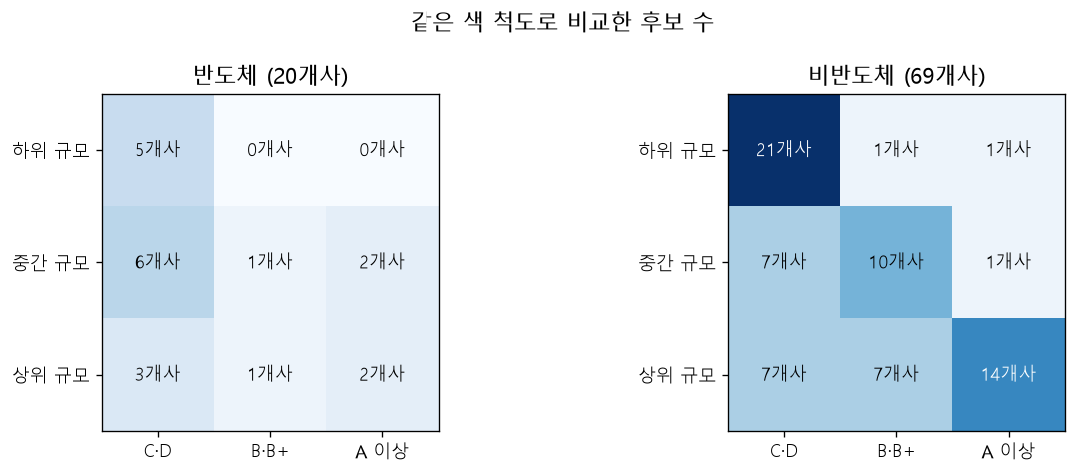

In [5]:
idx = pd.MultiIndex.from_product([SECTORS,CAP_LABELS],names=['업종군','규모군'])
segment = pd.crosstab([latest['업종군'],latest['규모군']],latest['등급군']).reindex(index=idx,columns=GRADE_GROUPS,fill_value=0)
assert int(segment.to_numpy().sum()) == len(latest)
display(segment.assign(합계=segment.sum(axis=1)))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,s in zip(axes,SECTORS):
    vals=segment.loc[s].to_numpy()
    ax.imshow(vals,cmap='Blues',vmin=0,vmax=max(1,segment.to_numpy().max()))
    ax.set_xticks(range(3),GRADE_GROUPS)
    ax.set_yticks(range(3),CAP_LABELS)
    ax.set_title(f'{s} ({latest["업종군"].eq(s).sum()}개사)')
    for i in range(3):
        for j in range(3):
            ax.text(j,i,f'{vals[i,j]}개사',ha='center',va='center',color='white' if vals[i,j]>segment.to_numpy().max()/2 else 'black')
fig.suptitle('같은 색 척도로 비교한 후보 수')
fig.tight_layout()
plt.show()


## 6. 컨설팅 내용의 단서: E·S·G와 보고서
환경·사회·지배구조 각각 C·D인 기업 비율로 어떤 과제부터 진단할지 살펴봅니다. 같은 기업이 여러 영역에 포함되므로 영역별 기업 수를 더하면 중복됩니다.

보고서는 두 발행 플래그로 유형을 다시 구성합니다. **미발행은 공시 형식의 공백 가능성**이며, ESG 활동 부재나 컨설팅 수요 확정을 의미하지 않습니다. 발행 기업의 등급이 더 높더라도 보고서가 등급 상승을 일으켰다고 해석할 수 없습니다.

보고서유형_재구성,둘 다 발행,미발행,지배구조만,지속가능경영만
보고서_발행_유형,,,,
둘 다 발행,34,0,0,0
미발행,0,40,0,0
지배구조만,0,0,6,0
지속가능경영만,0,0,0,9


등급군             C·D  B·B+  A 이상
업종군  보고서유형_재구성                 
반도체  둘 다 발행       1     1     4
     미발행         11     0     0
     지속가능경영만      2     1     0
비반도체 둘 다 발행       4    10    14
     미발행         25     3     1
     지배구조만        2     3     1
     지속가능경영만      4     2     0

,업종군,영역,C·D 기업수,분모,C·D 비율(%)
0,반도체,환경,12,20,60.0
1,반도체,사회,9,20,45.0
2,반도체,지배구조,13,20,65.0
3,비반도체,환경,30,69,43.5
4,비반도체,사회,28,69,40.6
5,비반도체,지배구조,40,69,58.0


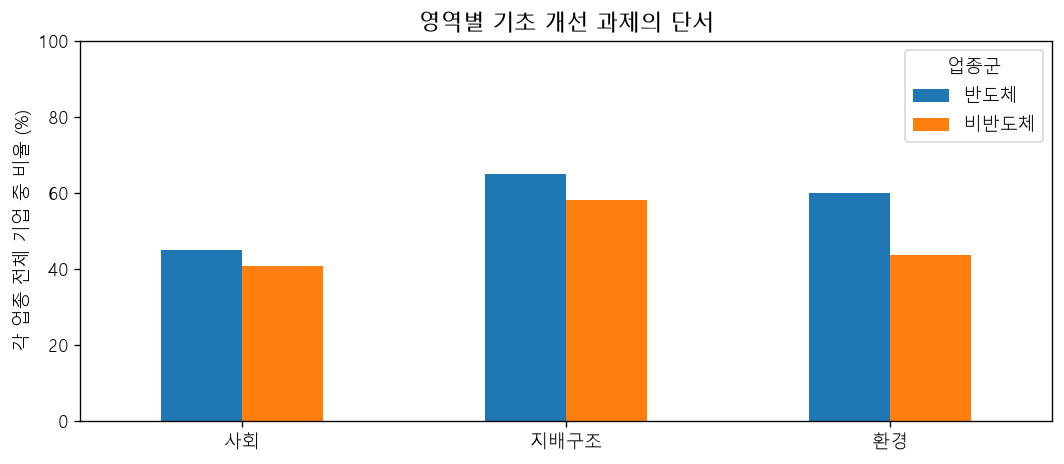

,기업명,ESG등급,보고서유형_재구성,비고,원준 확인
26,네패스,C,지속가능경영만,,
30,대덕전자,B+,지배구조만,,지속가능경영보고서없어서 점수 낮게 나온듯
42,대주전자재료,B+,지속가능경영만,웹리포트,
104,서울반도체,C,미발행,홈페이지 ESG 관련 활동만 명시,
141,신성이엔지,C,둘 다 발행,"24년 데이터로 25년에 홈페이지에 발행, 이름 '지속가능경영보고서 24'",
161,아이티엠반도체,B+,미발행,공홈에 성과 공개,
190,엠씨넥스,B+,지배구조만,https://www.mcnex.com/ko/esg/Mcnex_ESG_ESG_Report,지속가능경영보고서 반영 안 됨
202,이수페타시스,B,둘 다 발행,"25년 웹 지속가능경영보고서 발행,\nhttps://esg.petasys.com:8...",
208,인탑스,B+,미발행,홈페이지에 ESG관련 활동 명시,
215,인텔리안테크,C,지속가능경영만,DB제대로 안됨,해당폴더에 지속가능경영보고서가 2024로 등록되어있어서 수정


해석: 비고에 웹리포트·홈페이지 공개·보고서 반영 이슈가 있으면 접촉 전에 발행 상태를 확인하세요.


In [6]:
for c in ['지속가능경영보고서_발행','기업지배구조보고서_발행']:
    assert set(latest[c].dropna()) <= {0,1}
sr=latest['지속가능경영보고서_발행'].eq(1)
gr=latest['기업지배구조보고서_발행'].eq(1)
latest['보고서유형_재구성']=np.select([sr&gr,sr&~gr,~sr&gr],['둘 다 발행','지속가능경영만','지배구조만'],default='미발행')
display(pd.crosstab(latest['보고서_발행_유형'],latest['보고서유형_재구성']))
display(pd.crosstab([latest['업종군'],latest['보고서유형_재구성']],latest['등급군']).reindex(columns=GRADE_GROUPS,fill_value=0))
weak=[]
for s in SECTORS:
    part=latest[latest['업종군'].eq(s)]
    for c in ['환경','사회','지배구조']:
        n=part[c].isin(['C','D']).sum()
        weak.append({'업종군':s,'영역':c,'C·D 기업수':n,'분모':len(part),'C·D 비율(%)':100*n/len(part)})
weak=pd.DataFrame(weak)
display(weak)
ax=weak.pivot(index='영역',columns='업종군',values='C·D 비율(%)').plot.bar(figsize=(9,4),rot=0,ylim=(0,100))
ax.set(ylabel='각 업종 전체 기업 중 비율 (%)',xlabel='',title='영역별 기초 개선 과제의 단서')
plt.tight_layout()
plt.show()
review=latest.loc[latest['비고'].notna()|latest['원준 확인'].notna()|latest['기업명'].eq('네패스'),
 ['기업명','ESG등급','보고서유형_재구성','비고','원준 확인']]
display(review.fillna(''))
print('해석: 비고에 웹리포트·홈페이지 공개·보고서 반영 이슈가 있으면 접촉 전에 발행 상태를 확인하세요.')


## 7. 과거 등급 변화: 같은 기업만 비교
2024년과 2025년 모두 있는 기업의 ESG등급 순서를 비교합니다. 개선·유지·하락은 기록된 등급의 방향만 뜻하며, 평가 방법이나 원인 변화를 통제한 성과 측정이 아닙니다. 2025년 업종 구분으로 묶고, 과거 시가총액은 추정하지 않습니다.

In [7]:
previous = df.loc[df['평가년도'].eq(year-1),['기업코드','ESG등급']].rename(columns={'ESG등급':'전년등급'})
latest = latest.merge(previous,on='기업코드',how='left',validate='one_to_one')
delta=latest['ESG등급'].map(GRADE_SCORE)-latest['전년등급'].map(GRADE_SCORE)
latest['등급변화']=np.select([latest['전년등급'].isna(),delta.gt(0),delta.lt(0)],
                              ['전년 비교 불가','개선','하락'],default='유지')
display(pd.crosstab(latest['업종군'],latest['등급변화']).reindex(SECTORS))
paired=latest.dropna(subset=['전년등급'])
display(pd.crosstab(paired['전년등급'],paired['ESG등급']).reindex(index=GRADE_ORDER,columns=GRADE_ORDER,fill_value=0))
print(f'동일 기업 비교: {len(paired)}개사 / 최신 기업 {len(latest)}개사')
display(latest.loc[latest['등급변화'].eq('하락'),['기업명','업종군','전년등급','ESG등급','시가총액_억원']].sort_values('시가총액_억원',ascending=False))


등급변화,개선,유지,전년 비교 불가,하락
업종군,,,,
반도체,5,10,1,4
비반도체,14,43,0,12


ESG등급,D,C,B,B+,A,A+,S
전년등급,,,,,,,
D,23,3,0,0,0,0,0
C,11,10,4,3,0,0,0
B,0,0,2,4,0,0,0
B+,0,1,1,5,5,0,0
A,0,0,0,1,12,0,0
A+,0,0,0,0,2,1,0
S,0,0,0,0,0,0,0


동일 기업 비교: 88개사 / 최신 기업 89개사


,기업명,업종군,전년등급,ESG등급,시가총액_억원
21,삼성SDI,비반도체,A+,A,"217,178.0"
66,포스코퓨처엠,비반도체,A+,A,"166,329.0"
73,효성중공업,비반도체,B+,B,"166,070.0"
35,신성델타테크,비반도체,C,D,"15,583.4"
59,제이앤티씨,비반도체,C,D,"11,465.6"
1,경동나비엔,비반도체,A,B+,"8,085.6"
32,솔루엠,비반도체,B+,C,"7,932.7"
62,케이엠더블유,비반도체,C,D,"5,893.9"
22,삼영전자공업,비반도체,C,D,"2,108.0"
50,와이투솔루션,반도체,C,D,"1,516.0"


## 8. 후보 시나리오 비교
**A 기초 개선형:** C·D × 중간 규모. 기초 진단·지표 관리·공시 체계 정비 수요를 확인할 첫 가설입니다.  
**B 등급 향상형:** B·B+ × 중간 규모. 기존 체계의 약한 영역을 보완할 수 있는지 확인합니다.  
**C 소규모 기초형:** C·D × 하위 규모. 표준화된 진단 서비스가 가능한지, 예산과 담당 인력이 있는지 확인합니다.  
**D 대형 개선형:** C·D × 상위 규모. 규모가 큰 개선 과제 후보지만 제안·수행 범위도 커질 수 있습니다.

A~D는 우열을 뜻하지 않습니다. A 이상은 이번 ‘등급 개선’ 중심 후보 시나리오에서 제외했을 뿐, 고도화 컨설팅 수요가 없다는 뜻은 아닙니다.

In [8]:
scenario_specs = {
    'A 기초 개선형': ('C·D','중간 규모'),
    'B 등급 향상형': ('B·B+','중간 규모'),
    'C 소규모 기초형': ('C·D','하위 규모'),
    'D 대형 개선형': ('C·D','상위 규모'),
}
rows=[]
latest['시나리오']='기타'
for label,(grade,cap) in scenario_specs.items():
    mask=latest['등급군'].eq(grade)&latest['규모군'].eq(cap)
    latest.loc[mask,'시나리오']=label
    for s in SECTORS:
        p=latest.loc[mask&latest['업종군'].eq(s)]
        rows.append({'시나리오':label,'업종군':s,'기업수':len(p),
            '시총중앙값_억원':p['시가총액_억원'].median(),
            '보고서 모두 미발행':p['보고서유형_재구성'].eq('미발행').sum(),
            '전년 하락':p['등급변화'].eq('하락').sum(),
            '전년 비교 가능':p['전년등급'].notna().sum(),
            '기업목록':', '.join(p['기업명']) or '없음'})
comparison=pd.DataFrame(rows)
display(comparison)
print('숫자는 기업 수입니다. 미발행·하락은 겹칠 수 있으며, 추천 점수로 합산하지 않습니다.')


,시나리오,업종군,기업수,시총중앙값_억원,보고서 모두 미발행,전년 하락,전년 비교 가능,기업목록
0,A 기초 개선형,반도체,6,"5,175.2",4,0,5,"네패스, 서울반도체, 신성이엔지, 에프에스티, RFHIC, SFA반도체"
1,A 기초 개선형,비반도체,7,"5,893.9",3,2,7,"덕산네오룩스, 삼화콘덴서공업, 솔루엠, 신도리코, 인텔리안테크, 케이엠더블유, 파트론"
2,B 등급 향상형,반도체,1,"8,524.2",0,0,1,하나머티리얼즈
3,B 등급 향상형,비반도체,10,"5,276.7",2,1,10,"경동나비엔, 대주전자재료, 드림텍, 비에이치, 세방전지, 솔루스첨단소재, 엠씨넥스,..."
4,C 소규모 기초형,반도체,5,"1,044.2",5,4,5,"광전자, 시그네틱스, 와이투솔루션, 주성코퍼레이션, KEC"
5,C 소규모 기초형,비반도체,21,557.8,18,4,21,"경인전자, 광명전기, 금호전기, 대동전자, 대원전선, 더블유씨피, 삼영전자공업, 삼..."
6,D 대형 개선형,반도체,3,"17,092.4",2,0,3,"리노공업, 에스앤에스텍, 하나마이크론"
7,D 대형 개선형,비반도체,7,"14,276.7",4,2,7,"서진시스템, 신성델타테크, 에스피지, 일진전기, 제이앤티씨, 코리아써키트, DN오토모티브"


숫자는 기업 수입니다. 미발행·하락은 겹칠 수 있으며, 추천 점수로 합산하지 않습니다.


## 9. 경계값 민감도: 규모 기준을 바꿔도 후보가 남는가?
중간 규모의 하한을 1천억·3천억·5천억, 상한을 1조·2조로 바꿔 A·B군의 후보 수를 비교합니다. 기본안과 겹치는 기업 수, 추가·제외 기업 수를 함께 표시합니다. 변화가 크면 먼저 대상 규모에 대한 팀 합의가 필요합니다. 분위수는 분포 참고값이며 기본안을 정당화하는 검정이 아닙니다.

In [9]:
sensitivity=[]
for lo in [1000e8,3000e8,5000e8]:
    for hi in [1e12,2e12]:
        for s in SECTORS:
            for g in ['C·D','B·B+']:
                p=latest.loc[latest['업종군'].eq(s)&latest['등급군'].eq(g)]
                base=set(p.loc[p['시가총액'].ge(LOWER_CAP)&p['시가총액'].lt(UPPER_CAP),'기업코드'])
                new=set(p.loc[p['시가총액'].ge(lo)&p['시가총액'].lt(hi),'기업코드'])
                sensitivity.append({'하한_억원':lo/1e8,'상한미만_억원':hi/1e8,'업종군':s,'등급군':g,
                                    '기업수':len(new),'기본안 유지':len(new&base),'추가':len(new-base),'제외':len(base-new)})
display(pd.DataFrame(sensitivity))
display(latest.groupby('업종군')['시가총액_억원'].quantile([.25,.5,.75]).unstack().rename(columns={.25:'25% 분위',.5:'중앙값',.75:'75% 분위'}))
print('해석: 업종별 후보 수와 규모 분포가 다르므로 같은 경계가 같은 비율의 기업을 뽑지는 않습니다.')


,하한_억원,상한미만_억원,업종군,등급군,기업수,기본안 유지,추가,제외
0,"1,000.0","10,000.0",반도체,C·D,9,6,3,0
1,"1,000.0","10,000.0",반도체,B·B+,1,1,0,0
2,"1,000.0","10,000.0",비반도체,C·D,17,7,10,0
3,"1,000.0","10,000.0",비반도체,B·B+,11,10,1,0
4,"1,000.0","20,000.0",반도체,C·D,11,6,5,0
5,"1,000.0","20,000.0",반도체,B·B+,1,1,0,0
6,"1,000.0","20,000.0",비반도체,C·D,23,7,16,0
7,"1,000.0","20,000.0",비반도체,B·B+,13,10,3,0
8,"3,000.0","10,000.0",반도체,C·D,6,6,0,0
9,"3,000.0","10,000.0",반도체,B·B+,1,1,0,0


,25% 분위,중앙값,75% 분위
업종군,,,
반도체,"2,832.2","7,759.0","12,001.6"
비반도체,"1,934.5","6,386.3","20,487.7"


해석: 업종별 후보 수와 규모 분포가 다르므로 같은 경계가 같은 비율의 기업을 뽑지는 않습니다.


## 9-1. 추가 세그먼트: 자산총액 2조원 기준
**사용자 제시 분석 가정: 2030년 의무공시를 고려하여 자산총액 2조원 이상을 별도 후보군으로 비교합니다.** 시행 일정·법적 적용 범위는 이번 분석에서 검증하지 않았으므로 ‘의무공시 확정 대상’ 판정은 아닙니다. **2025 사업연도 자산은 현재 후보 발굴에 쓰는 기준이며 2030년 자산을 예측한 값이 아닙니다.**

시가총액은 주식의 시장 가치, 자산총액은 재무제표의 자산 규모입니다. 기존 시가총액 구분과 별도로 DART 자산총액을 적용합니다.

| 자산 기준군 | 규칙 |
|---|---|
| 2조원 이상 | 자산총액 ≥ 2조원 |
| 2조원 미만 | 0 ≤ 자산총액 < 2조원 |
| 확인 필요 | 자료 없음·연결 오류·계정 또는 통화 확인 필요 |

**원화 외 통화 공시:** 아남전자(008700)는 연결·별도 모두 **USD 표시 재무제표**를 공시합니다(자산총계 144,149,370 USD, 제 53 기). 임의 환율로 환산하지 않았으므로 자산기준군은 확인 필요로 남기고, 공시 금액과 통화는 `자산총액_표시통화금액`·`통화` 열에 보존했습니다. 참고로 900~2,000원/USD 구간에서 약 1,300억~2,900억원이므로 2조원 경계 부근은 아닙니다. 이 환산은 참고 수치일 뿐 분류에 반영하지 않았습니다.

2025 사업연도 사업보고서의 자산총계를 연결 우선으로 수집합니다. 연결 자료가 없다는 응답(013)일 때만 별도를 조회합니다. 과거 연도 값으로 채우지 않고 기업별 기준·공시 출처를 보존합니다.

### DART 자산총액 조회
[공식 전체 재무제표 API 가이드](https://opendart.fss.or.kr/guide/detail.do?apiGrpCd=DS003&apiId=2019020)와 [고유번호 가이드](https://opendart.fss.or.kr/guide/detail.do?apiGrpCd=DS001&apiId=2019018)를 따릅니다.

- 6자리 종목코드 → 8자리 DART 고유번호로 연결합니다.
- **2025 사업연도·사업보고서(11011)·재무상태표(BS)·자산총계 당기금액·KRW**를 사용합니다. 비12월 결산 기업일 수 있으므로 이를 일괄 ‘2025년 12월 말’이라고 표기하지 않습니다.
- 연결 우선이며, 연결 조회자료가 없을 때만 별도를 조회합니다. 계정·통화·금액에 문제가 있으면 확인 필요로 남깁니다.
- 원화 외 통화로 공시한 기업은 환산하지 않고 확인 필요로 두되, 공시 금액과 통화를 `자산총액_표시통화금액`·`통화` 열에 보존해 팀이 환율 가정을 정한 뒤 직접 판단할 수 있게 합니다.
- 기업별 연결/별도 기준, 당기명, 접수번호, 원문 링크, 조회시각을 보존합니다. 기준이 섞일 수 있으므로 법적 적용 판단 전 확인해야 합니다.
- 인증키는 재조회 시 환경변수 또는 지정한 `dart.txt`에서 읽으며 노트북과 수집 결과에 저장하지 않습니다. 기본 재실행은 저장된 수집 결과 JSON을 사용합니다.
- `DART_REFRESH=True`로 재조회하면 결과를 같은 이름의 수집 결과 JSON으로 덮어써 저장하므로, 다음 실행은 인증키 없이 같은 표를 재현합니다.
- 팀 공유 시 노트북·두 원본 엑셀·수집 결과 JSON을 함께 전달하면 API 인증키 없이 같은 표를 재현할 수 있습니다. 재조회 시 고정 요약 문단의 수치도 갱신해야 합니다.

In [10]:
import os
import io
import json
import zipfile
import time
import re
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
from datetime import datetime, timezone

DART_YEAR = 2025
DART_COLUMNS = ['기업코드','DART기업명','DART고유번호','자산총액_원','자산총액_표시통화금액',
                '재무제표기준','사업연도','당기명','통화','접수번호','공시출처','조회시각_UTC','조회상태']
DART_REFRESH = False  # 환경변수 인증키가 있을 때 실제 조회

def dart_bytes(endpoint, key, **params):
    # 인증키·요청 URL을 출력하거나 오류 메시지에 포함하지 않습니다.
    query = urllib.parse.urlencode(dict(crtfc_key=key, **params))
    request = urllib.request.Request('https://opendart.fss.or.kr/api/'+endpoint+'?'+query)
    for attempt in range(3):
        try:
            with urllib.request.urlopen(request, timeout=40) as response:
                return response.read()
        except Exception:
            if attempt == 2:
                raise RuntimeError('DART 통신 실패: 네트워크 연결을 확인하세요.') from None
            time.sleep(attempt+1)

def dart_company_map(key):
    payload = dart_bytes('corpCode.xml', key)
    if not zipfile.is_zipfile(io.BytesIO(payload)):
        raise RuntimeError('DART 고유번호 다운로드 실패: 인증키 또는 서비스 상태를 확인하세요.')
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        root = ET.fromstring(archive.read('CORPCODE.xml'))
    mapping = {}
    for item in root.findall('list'):
        stock = (item.findtext('stock_code') or '').strip()
        if re.fullmatch(r'\d{6}', stock):
            mapping.setdefault(stock, []).append({
                'DART고유번호':item.findtext('corp_code'),
                'DART기업명':item.findtext('corp_name')})
    return mapping

def select_dart_assets(rows):
    # 재무상태표 자산총계의 당기 금액만 사용. 유동/비유동 자산을 오인하지 않습니다.
    bs = [r for r in rows if r.get('sj_div') == 'BS']
    selected = [r for r in bs if r.get('account_id') in ('ifrs-full_Assets','ifrs_Assets')]
    if not selected:
        selected = [r for r in bs if re.sub(r'\s','',r.get('account_nm','')) in ('자산총계','총자산','자산합계')]
    if not selected:
        return None, '자산총계 계정 확인 필요'
    values = []
    for row in selected:
        amount = str(row.get('thstrm_amount','')).replace(',','').strip()
        if not re.fullmatch(r'\d+',amount):
            return None, '자산 금액 확인 필요'
        values.append(int(amount))
    if len(set(values)) != 1:
        return None, '자산총계 중복값 충돌'
    base = dict(selected[0], parsed_amount=values[0])
    if {r.get('currency') for r in selected} != {'KRW'}:
        # 원화 외 통화는 공시 금액과 통화를 그대로 남기고 임의 환율로 환산하지 않습니다.
        return dict(base, parsed_assets=None), '통화 확인 필요'
    return dict(base, parsed_assets=values[0]), '성공'

def fetch_dart_assets(stocks, key, year=2025):
    mapping = dart_company_map(key)
    results = []
    for i,stock in enumerate(stocks,1):
        row = dict.fromkeys(DART_COLUMNS)
        row.update(기업코드=stock, 사업연도=year,
                   조회시각_UTC=datetime.now(timezone.utc).isoformat())
        matches = mapping.get(stock,[])
        if len(matches) != 1:
            row['조회상태'] = 'DART 고유번호 없음' if not matches else 'DART 고유번호 중복'
            results.append(row)
            continue
        row.update(matches[0])
        for basis in ['CFS','OFS']:
            payload = json.loads(dart_bytes('fnlttSinglAcntAll.json',key,
                corp_code=row['DART고유번호'], bsns_year=str(year), reprt_code='11011', fs_div=basis))
            status = payload.get('status')
            if status == '013':
                row['조회상태'] = '해당 사업연도 재무제표 없음'
                continue
            if status != '000':
                # 인증 실패/호출 제한을 자료 없음으로 바꾸지 않습니다.
                raise RuntimeError('DART API 조회 중단: 상태 코드 '+str(status))
            selected, message = select_dart_assets(payload.get('list',[]))
            row['조회상태'] = message
            row['재무제표기준'] = '연결' if basis == 'CFS' else '별도'
            if selected:
                row.update(자산총액_원=selected['parsed_assets'],
                           자산총액_표시통화금액=selected['parsed_amount'],
                           당기명=selected.get('thstrm_nm'), 통화=selected.get('currency'),
                           접수번호=selected.get('rcept_no'),
                           공시출처='https://dart.fss.or.kr/dsaf001/main.do?rcpNo='+selected.get('rcept_no',''))
            # 연결 응답이 있으나 계정에 문제가 있으면 별도로 조용히 대체하지 않습니다.
            break
        results.append(row)
        if i % 10 == 0 or i == len(stocks):
            print(f'DART 조회 {i}/{len(stocks)}')
        time.sleep(.12)
    return pd.DataFrame(results,columns=DART_COLUMNS)

# 기본 재실행은 저장된 수집 결과를 사용합니다. DART_REFRESH=True일 때만 재조회합니다.
DART_SNAPSHOT = INPUT_PATH.parent / 'DART_자산총액_2025.json'
if DART_REFRESH:
    dart_key = (os.environ.get('DART_API_KEY') or os.environ.get('OPENDART_API_KEY') or
                os.environ.get('DART_CRTFC_KEY') or '').strip()
    if not dart_key:
        key_file = INPUT_PATH.parent / 'dart.txt'
        if key_file.is_file():
            key_text = key_file.read_text(encoding='utf-8-sig')
            matches = re.findall(r'(?<![a-zA-Z0-9])[a-zA-Z0-9]{40}(?![a-zA-Z0-9])',key_text)
            key_text = None
            if len(matches) == 1:
                dart_key = matches[0]
            matches = None
    if not dart_key:
        raise RuntimeError('DART 인증키가 없습니다. 환경변수 또는 dart.txt를 확인하세요.')
    try:
        dart_assets = fetch_dart_assets(latest['기업코드'].tolist(),dart_key,DART_YEAR)
    finally:
        dart_key = None
    # 재조회 결과를 수집 결과 파일로 저장해 다음 실행이 인증키 없이 같은 표를 재현하도록 합니다.
    DART_SNAPSHOT.write_text(dart_assets.to_json(orient='records',indent=2,force_ascii=False),encoding='utf-8')
    print('수집 결과 저장:',DART_SNAPSHOT.name)
else:
    assert DART_SNAPSHOT.is_file(), '수집 결과 JSON을 같은 폴더에 두거나 DART_REFRESH=True로 조회하세요.'
    dart_assets = pd.DataFrame(json.loads(DART_SNAPSHOT.read_text(encoding='utf-8')))
    print('수집 결과:',DART_SNAPSHOT.name)
    print('SHA256:',hashlib.sha256(DART_SNAPSHOT.read_bytes()).hexdigest())

assert set(dart_assets['기업코드']) == set(latest['기업코드'])
assert dart_assets['기업코드'].is_unique
assert dart_assets['사업연도'].eq(DART_YEAR).all()
success = dart_assets['조회상태'].eq('성공')
assert dart_assets.loc[success,'통화'].eq('KRW').all()
assert pd.to_numeric(dart_assets.loc[success,'자산총액_원']).ge(0).all()
ASSET_BY_CODE = dart_assets.loc[success].set_index('기업코드')['자산총액_원'].to_dict()
ASSET_BASE_YEAR = DART_YEAR
ASSET_SCOPE = '연결 우선, 연결 조회자료 없음(013)일 때 별도; 기업별 기준 참조'
latest = latest.merge(dart_assets[['기업코드','DART기업명','재무제표기준','사업연도','당기명','조회상태','공시출처']],
                      on='기업코드',how='left',validate='one_to_one')
display(dart_assets)
display(dart_assets.groupby(['조회상태','재무제표기준'],dropna=False).size().rename('기업수').to_frame())
non_krw = dart_assets.loc[dart_assets['통화'].notna() & dart_assets['통화'].ne('KRW'),
    ['기업코드','DART기업명','자산총액_표시통화금액','통화','당기명','재무제표기준','접수번호','공시출처']]
if len(non_krw):
    print('원화 외 통화로 공시한 기업입니다. 환율 가정을 두지 않았으므로 확인 필요로 남깁니다.')
    display(non_krw)
print('이름은 종목코드로 연결합니다. 원본 회사명과 DART 법인명 차이는 아래에서 확인하세요.')
display(latest.loc[latest['기업명'].ne(latest['DART기업명']),['기업코드','기업명','DART기업명']])


수집 결과: DART_자산총액_2025.json
SHA256: a404a7fa1da552acdaad8d887806cf688c9b06927a436df0f65c514d0de19fc9


,기업코드,DART기업명,DART고유번호,자산총액_원,자산총액_표시통화금액,재무제표기준,사업연도,당기명,통화,접수번호,공시출처,조회시각_UTC,조회상태
0,000500,가온전선,00104768,"1,377,927,912,000.0",1377927912000,연결,2025,제 78 기,KRW,20260316000969,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:54.718792+00:00,성공
1,009450,경동나비엔,00101488,"1,522,167,095,867.0",1522167095867,연결,2025,제 53 기,KRW,20260318001570,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:55.017515+00:00,성공
2,009140,경인전자,00102140,"87,287,055,386.0",87287055386,연결,2025,제 53 기,KRW,20260312001118,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:55.334377+00:00,성공
3,017040,광명전기,00103662,"134,086,469,248.0",134086469248,별도,2025,제 45 기,KRW,20260407003303,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:55.640315+00:00,성공
4,017900,광전자,00152729,"258,292,978,185.0",258292978185,연결,2025,제 42 기,KRW,20260319000424,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:56.053344+00:00,성공
5,001210,금호전기,00106395,"30,776,225,371.0",30776225371,연결,2025,제 72 기,KRW,20260318001105,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:56.326549+00:00,성공
6,033640,네패스,00227333,"696,198,458,357.0",696198458357,연결,2025,제 36 기,KRW,20260318001666,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:56.584519+00:00,성공
7,353200,대덕전자,01478712,"1,178,006,544,303.0",1178006544303,연결,2025,제 6 기,KRW,20260318001514,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:56.880577+00:00,성공
8,008110,대동전자,00157104,"286,197,637,419.0",286197637419,연결,2025,제 53 기,KRW,20250619000257,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:57.165799+00:00,성공
9,006340,대원전선,00260392,"346,448,665,318.0",346448665318,연결,2025,제 57 기,KRW,20260331003244,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-09-07T08:18:57.453477+00:00,성공


기업수
조회상태     재무제표기준     
성공       별도        4
         연결       84
통화 확인 필요 연결        1

원화 외 통화로 공시한 기업입니다. 환율 가정을 두지 않았으므로 확인 필요로 남깁니다.


,기업코드,DART기업명,자산총액_표시통화금액,통화,당기명,재무제표기준,접수번호,공시출처
40,008700,아남전자,144149370,USD,제 53 기,연결,20260312001247,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...


이름은 종목코드로 연결합니다. 원본 회사명과 DART 법인명 차이는 아래에서 확인하세요.


,기업코드,기업명,DART기업명


자산기준군,2조원 이상,2조원 미만,확인 필요,전체기업수
업종군,,,,
반도체,4,16,0,20
비반도체,20,48,1,69


자산 값 확인 88개사 / 확인 필요 1개사
자산 기준연도: 2025 / 재무제표 기준: 연결 우선, 연결 조회자료 없음(013)일 때 별도; 기업별 기준 참조


등급군          C·D  B·B+  A 이상  합계
업종군  자산기준군                      
반도체  2조원 이상    1     1     2   4
     2조원 미만   13     1     2  16
     확인 필요     0     0     0   0
비반도체 2조원 이상    2     6    12  20
     2조원 미만   32    12     4  48
     확인 필요     1     0     0   1

자산기준군           2조원 이상  2조원 미만  확인 필요
업종군  시나리오                            
반도체  A 기초 개선형        0       6      0
     B 등급 향상형        0       1      0
     C 소규모 기초형       0       5      0
     D 대형 개선형        1       2      0
     기타              3       2      0
비반도체 A 기초 개선형        0       7      0
     B 등급 향상형        2       8      0
     C 소규모 기초형       0      20      1
     D 대형 개선형        2       5      0
     기타             16       8      0

재무제표 기준별 자산 구분: 연결과 별도가 섞이는지 함께 확인하세요.


자산기준군,2조원 이상,2조원 미만,확인 필요
재무제표기준,,,
별도,0,4,0
연결,24,60,1


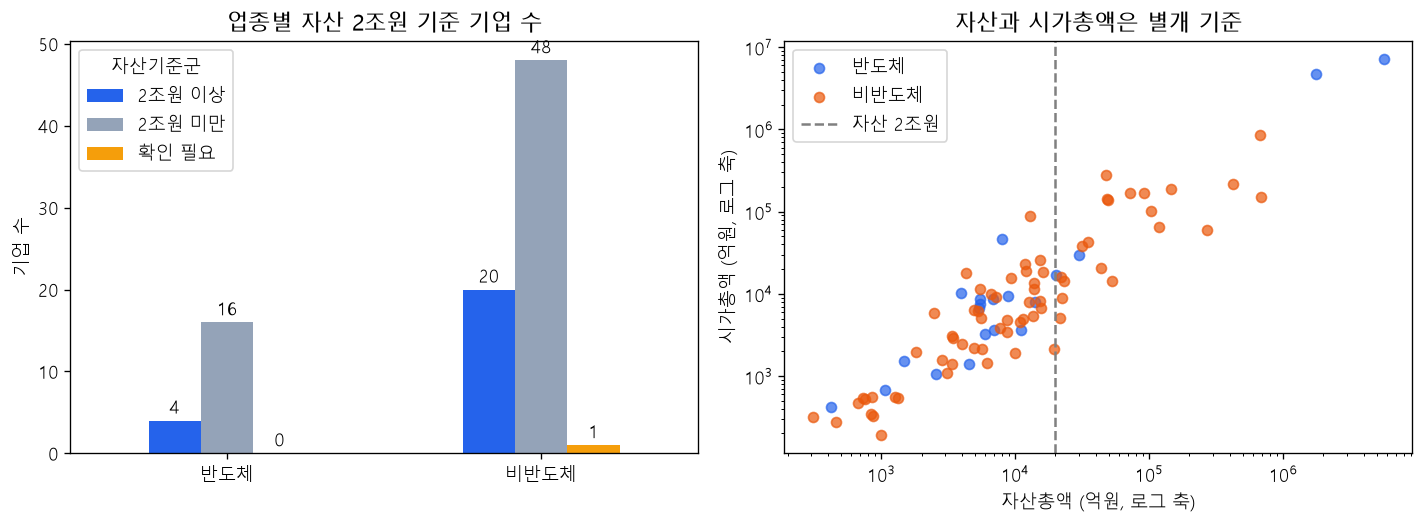

자산 2조원 이상 기업 목록: 등급·규모·보고서 상태로 서비스 적합성을 비교하세요.


,기업코드,기업명,업종군,ESG등급,자산총액_억원,재무제표기준,시가총액_억원,보고서유형_재구성,시나리오,공시출처
20,005930,삼성전자,반도체,A,"5,669,421.1",연결,"7,097,645.9",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
88,000660,SK하이닉스,반도체,A,"1,761,076.6",연결,"4,739,295.4",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
75,000990,DB하이텍,반도체,B+,"29,925.8",연결,"29,409.1",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
67,067310,하나마이크론,반도체,C,"20,178.4",연결,"17,092.4",지속가능경영만,D 대형 개선형,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
83,066570,LG전자,비반도체,A,"686,201.7",연결,"149,693.0",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
81,373220,LG에너지솔루션,비반도체,A,"671,479.5",연결,"862,290.0",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
21,006400,삼성SDI,비반도체,A,"422,553.4",연결,"217,178.0",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
80,034220,LG디스플레이,비반도체,A,"269,167.0",연결,"59,050.0",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
19,009150,삼성전기,비반도체,A,"145,959.0",연결,"190,469.0",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...
82,011070,LG이노텍,비반도체,A,"119,308.8",연결,"64,137.9",둘 다 발행,기타,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...


In [11]:
ASSET_GROUPS = ['2조원 이상','2조원 미만','확인 필요']
assert set(ASSET_BY_CODE) <= set(latest['기업코드']), '자산 입력 기업코드를 확인하세요.'
if ASSET_BY_CODE:
    assert ASSET_BASE_YEAR is not None and ASSET_SCOPE, '자산 기준연도와 연결/별도 기준을 기록하세요.'
asset_values = pd.to_numeric(latest['기업코드'].map(ASSET_BY_CODE), errors='raise')
assert asset_values.dropna().ge(0).all(), '음수 자산 입력을 확인하세요.'
assert np.isfinite(asset_values.dropna()).all(), '무한대 자산 입력을 확인하세요.'
latest['자산총액_억원'] = asset_values/1e8
latest['자산기준군'] = np.select(
    [asset_values.isna(), asset_values.ge(ASSET_THRESHOLD)],
    ['확인 필요','2조원 이상'], default='2조원 미만')
asset_counts = pd.crosstab(latest['업종군'],latest['자산기준군']).reindex(
    index=SECTORS, columns=ASSET_GROUPS, fill_value=0)
display(asset_counts.assign(전체기업수=asset_counts.sum(axis=1)))
print(f'자산 값 확인 {asset_values.notna().sum()}개사 / 확인 필요 {asset_values.isna().sum()}개사')
print('자산 기준연도:', ASSET_BASE_YEAR, '/ 재무제표 기준:', ASSET_SCOPE)
asset_idx = pd.MultiIndex.from_product([SECTORS,ASSET_GROUPS],names=['업종군','자산기준군'])
asset_grade = pd.crosstab([latest['업종군'],latest['자산기준군']],latest['등급군']).reindex(
    index=asset_idx,columns=GRADE_GROUPS,fill_value=0)
display(asset_grade.assign(합계=asset_grade.sum(axis=1)))
display(pd.crosstab([latest['업종군'],latest['시나리오']],latest['자산기준군']).reindex(
    columns=ASSET_GROUPS,fill_value=0))
assert int(asset_counts.to_numpy().sum()) == len(latest)
assert int(asset_grade.to_numpy().sum()) == len(latest)
if asset_values.isna().all():
    print('현재 이상/미만의 0은 자산 미확보에 따른 미분류입니다. 자산 기준 대상 수로 해석하지 마세요.')

print('재무제표 기준별 자산 구분: 연결과 별도가 섞이는지 함께 확인하세요.')
display(pd.crosstab(latest['재무제표기준'].fillna('미확인'),latest['자산기준군']).reindex(columns=ASSET_GROUPS,fill_value=0))
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
asset_counts.plot.bar(ax=axes[0],rot=0,color=['#2563eb','#94a3b8','#f59e0b'])
axes[0].set(title='업종별 자산 2조원 기준 기업 수',xlabel='',ylabel='기업 수')
for container in axes[0].containers:
    axes[0].bar_label(container,fmt='%d',padding=2)
for sector,color in zip(SECTORS,['#2563eb','#ea580c']):
    part=latest.loc[latest['업종군'].eq(sector)&latest['자산총액_억원'].gt(0)]
    axes[1].scatter(part['자산총액_억원'],part['시가총액_억원'],label=sector,alpha=.7,color=color)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].axvline(20000,color='gray',linestyle='--',label='자산 2조원')
axes[1].set(xlabel='자산총액 (억원, 로그 축)',ylabel='시가총액 (억원, 로그 축)',title='자산과 시가총액은 별개 기준')
axes[1].legend()
fig.tight_layout()
plt.show()
print('자산 2조원 이상 기업 목록: 등급·규모·보고서 상태로 서비스 적합성을 비교하세요.')
display(latest.loc[latest['자산기준군'].eq('2조원 이상'),
    ['기업코드','기업명','업종군','ESG등급','자산총액_억원','재무제표기준','시가총액_억원','보고서유형_재구성','시나리오','공시출처']
    ].sort_values(['업종군','자산총액_억원'],ascending=[True,False]))


## 10. 팀 회의에서 확정할 항목
| 결정 항목 | 이번 제안 | 확정 시 기록할 내용 |
|---|---|---|
| 반도체 범위 | 지정 업종 목록 20개사 적용 완료 | 반도체 20개사·비반도체 69개사, 분류 근거표 참조 |
| 자산총액 | 2조원 이상 / 미만 / 확인 필요 | DART 2025 사업연도 수집 결과·기업별 연결/별도 확인, 의무공시 조건의 별도 확인 |
| 시가총액 | 원 단위 가정, 3천억·1조 경계 | 원본의 가격 기준일·단위, 채택 경계값 |
| 핵심 서비스 | A 기초 개선형과 B 등급 향상형 비교 | 우리 팀이 실제 제공할 서비스와 선택 이유 |
| 보고서 조건 | 제외 조건 대신 보조 태그 | 웹 공개·그룹 보고서 포함 여부, 충돌 메모 처리 |
| 과거 하락 | 추가 진단 신호 | 하락 기업을 우선할지, 비교 불가 기업의 처리 |
| 최종 후보 규모 | 업종별 가용 기업 수를 보고 결정 | 필요한 접촉 기업 수와 부족할 때 확대할 조건 |

**논의 출발점:** 반도체은 중간 규모 C·D 4개사를 먼저 살펴보고, B·B+ 1개사만으로는 선택 폭이 좁다는 점을 고려합니다. 비반도체은 중간 규모 C·D 9개사와 B·B+ 10개사를 서비스 적합성으로 비교합니다. 이번 분류는 사용자 지정 기준을 반영했습니다. 추가로 범위를 변경할 경우 후보 수를 재계산하세요.

**접촉 전에 확인할 정보:** 담당자·예산·컨설팅 의향·이미 진행 중인 프로젝트·실제 사업 범위. 이 자료에는 없으므로 EDA에서 임의로 채우지 않았습니다.

아래 전체 기업표를 회의 중 후보 검색과 분류 검토에 사용하세요. 표의 정렬 순서는 추천 순위가 아닙니다.

**자산 기준 의사결정:** ‘2조원 이상 × C·D’는 공시 준비와 기초 개선을 함께 검토할 후보, ‘2조원 이상 × B·B+’는 기존 체계 보완 후보로 비교합니다. 2조원 미만은 별도 영업 후보로 유지합니다. 이는 사용자 제시 기준에 따른 서비스 가설이며, 실제 의무공시 대상 확정 판정이 아닙니다.

In [12]:
catalog=latest[['기업코드','기업명','산업코드','분류근거','업종군','ESG등급','환경','사회','지배구조',
                '시가총액_억원','규모군','자산총액_억원','자산기준군','재무제표기준','사업연도','조회상태','공시출처','보고서유형_재구성','전년등급','등급변화','시나리오']].sort_values(
                ['업종군','시나리오','시가총액_억원'],ascending=[True,True,False])
display(catalog.reset_index(drop=True))
assert len(catalog)==len(latest) and catalog['기업코드'].is_unique
assert comparison['기업수'].sum()==latest['시나리오'].ne('기타').sum()
print('검증 완료: 기업·연도 중복 없음, 최신 기업 1행씩, 세그먼트 총합 일치, 시나리오 총합 일치.')


,기업코드,기업명,산업코드,분류근거,업종군,ESG등급,환경,사회,지배구조,시가총액_억원,규모군,자산총액_억원,자산기준군,재무제표기준,사업연도,조회상태,공시출처,보고서유형_재구성,전년등급,등급변화,시나리오
0,218410,RFHIC,C264,목록 포함 · C261 외,반도체,D,C,D,D,"8,653.4",중간 규모,"5,461.8",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,D,유지,A 기초 개선형
1,036540,SFA반도체,C2611,목록 포함 · C261,반도체,C,C,C,C,"7,524.1",중간 규모,"5,494.5",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,D,개선,A 기초 개선형
2,036810,에프에스티,C2629,목록 포함 · C261 외,반도체,C,C,B,D,"6,729.6",중간 규모,"5,400.7",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,C,유지,A 기초 개선형
3,046890,서울반도체,C2612,목록 포함 · C261,반도체,C,C,B,D,"3,620.8",중간 규모,"11,032.6",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,C,유지,A 기초 개선형
4,033640,네패스,C261,목록 포함 · C261,반도체,C,B,B+,C,"3,597.2",중간 규모,"6,962.0",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,지속가능경영만,<NA>,전년 비교 불가,A 기초 개선형
5,011930,신성이엔지,C2612,목록 포함 · C261,반도체,C,C,B,B,"3,270.9",중간 규모,"6,006.9",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,둘 다 발행,C,유지,A 기초 개선형
6,166090,하나머티리얼즈,C2612,목록 포함 · C261,반도체,B,B+,A+,D,"8,524.2",중간 규모,"6,856.1",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,지속가능경영만,B,유지,B 등급 향상형
7,011690,와이투솔루션,C2611,목록 포함 · C261,반도체,D,C,C,D,"1,516.0",하위 규모,"1,483.9",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,C,하락,C 소규모 기초형
8,092220,KEC,C2612,목록 포함 · C261,반도체,D,C,D,D,"1,397.3",하위 규모,"4,489.2",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,C,하락,C 소규모 기초형
9,017900,광전자,C2612,목록 포함 · C261,반도체,D,C,D,D,"1,044.2",하위 규모,"2,582.9",2조원 미만,연결,2025,성공,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,미발행,C,하락,C 소규모 기초형


검증 완료: 기업·연도 중복 없음, 최신 기업 1행씩, 세그먼트 총합 일치, 시나리오 총합 일치.


### 재실행 안내
필요한 Python 패키지는 pandas, numpy, matplotlib, openpyxl이며, 노트북을 열고 실행하려면 Jupyter 환경이 필요합니다. 두 엑셀·DART_자산총액_2025.json·노트북을 같은 폴더에 두고 위에서부터 실행하세요. 그림에 한글이 보이지 않으면 설치된 한글 폰트를 설정하세요.

데이터 입력은 지정한 평가 원본과 반도체 업종 목록, DART API 자산총액입니다. 원본을 수정하거나 DART API와 공시 출처를 이용하며, 별도 데이터 파일을 생성하지 않습니다. 기본안 변경 시 표·차트는 다시 실행하고, 고정된 설명 문단의 수치도 갱신하세요.